### Imports

In [1]:
# Import modules
import os
from matplotlib import pyplot as plt
import matplotlib as mpl
%matplotlib inline
import seaborn as sns
sns.set_style("ticks")
import jax
from jax import config
import numpy as np
import jax.numpy as jnp
from discodj.cosmology.cosmology import Cosmology
plt.rcParams['image.cmap'] = "rocket"
print(jax.__version__)

0.7.2


In [2]:
#from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
#mpl.use("pgf")
#mpl.rcParams.update({
#    "pgf.texsystem": "pdflatex",
#    "font.family": "serif",
#    "text.usetex": True,
#})

In [2]:
# Detect if a GPU is available
devices = jax.devices()
device = "gpu" if np.any([d.platform == "gpu" for d in devices]) else "cpu"
print(device)

gpu


In [3]:
cosmo = Cosmology(
            Omega_c=0.259605,  # cold dark matter content
             Omega_b=0.0488911,  # baryonic content (note: Disco-DJ so far only performs N-body simulations, no hydro; this is only used for the linear power spectrum!)
             h=0.67742,  # dimensionless Hubble constant
             n_s=0.96822,  # scalar spectral index
             sigma8=0.808992,  # amplitude of matter density fluctuations at a scale of 8 Mpc/h
             mnu = 0.0)

cosmo_nu = Cosmology(
            Omega_c=0.259605,  # cold dark matter content
             Omega_b=0.0488911,  # baryonic content (note: Disco-DJ so far only performs N-body simulations, no hydro; this is only used for the linear power spectrum!)
             h=0.67742,  # dimensionless Hubble constant
             n_s=0.96822,  # scalar spectral index
             sigma8=0.808992,  # amplitude of matter density fluctuations at a scale of 8 Mpc/h
             mnu = 0.1
)

In [5]:
a = jnp.geomspace(1e-6, 1.0, 500)
H = cosmo.H(a)
H_nu = cosmo_nu.H(a)

plt.figure(figsize=(7.0, 5.0))
plt.loglog(a, H,color='blue', label=r'$H$',lw=2)  
plt.loglog(a, H_nu,'r--', label=r'$H_{nu}$',lw=2)  
plt.xlabel(r'Scale factor $a$')
plt.ylabel(r'$H (km \cdot s^{-1} \cdot Mpc^{-1}$)')
plt.grid(True, which='both', ls='--')
plt.legend()
plt.show()
#plt.savefig('H_DJ.pgf')


#Plot relative deviation [(H_wnu/H)-1]
plt.figure(figsize=(7.0, 5.0))
plt.semilogx(a, abs(H_nu/H),color='blue', label=r'$H_{nu}/H $',lw=1)  
plt.xlabel(r'Scale factor $a$')
plt.ylabel(r'$H_{nu}/H $')
plt.grid(True, which='both', ls='--')
plt.legend()
plt.show()
#plt.savefig('Hdiff_DJ.pgf')

E0507 15:57:14.507099  953804 pjrt_stream_executor_client.cc:3314] Execution of replica 0 failed: INTERNAL: jaxlib/gpu/solver_handle_pool.cc:37: operation gpusolverDnCreate(&handle) failed: cuSolver internal error


XlaRuntimeError: INTERNAL: jaxlib/gpu/solver_handle_pool.cc:37: operation gpusolverDnCreate(&handle) failed: cuSolver internal error

In [ ]:
conKeV = 1.160451812e4  # conversion K/eV : 
Tcmb = 2.725  #  CMB temp (K)
Tnu0 = (4/11)**(1/3)*Tcmb # CNB temp (K) 
Tnu0_eV = Tnu0/conKeV   


#Optimal value for omega_nu for optinal fr0 ratio
print ( (cosmo_nu.Omega_m * (cosmo_nu.Omega_gamma + cosmo_nu.Omega_nu_rel)) / (0.975 * (cosmo_nu.Omega_gamma + cosmo_nu.Omega_nu_rel*(3.046/2.046))) - cosmo_nu.Omega_m)

-0.034565016544091276


In [5]:
a = jnp.geomspace(1e-6, 1.0, 500)
growth = cosmo.compute_unnormed_growth(a,1e-6)
growth_nu = cosmo_nu.compute_unnormed_growth(a,1e-6)

Norm_fact = growth["Dplus_unnormed_at_1"]
Norm_fact_nu = growth_nu["Dplus_unnormed_at_1"]

D1 = growth["Dplus"] 
D2 = growth["D2plus"] 
D1_nu = growth_nu["Dplus"] #* Norm_fact_nu / Norm_fact
D2_nu = growth_nu["D2plus"] #* Norm_fact_nu / Norm_fact

E0507 16:01:41.265114  954158 pjrt_stream_executor_client.cc:3314] Execution of replica 0 failed: INTERNAL: jaxlib/gpu/solver_handle_pool.cc:37: operation gpusolverDnCreate(&handle) failed: cuSolver internal error


XlaRuntimeError: INTERNAL: jaxlib/gpu/solver_handle_pool.cc:37: operation gpusolverDnCreate(&handle) failed: cuSolver internal error

In [6]:
print(Norm_fact)
print(Norm_fact_nu)

NameError: name 'Norm_fact' is not defined

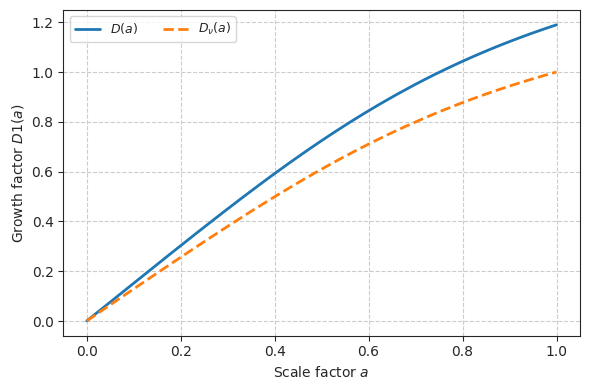

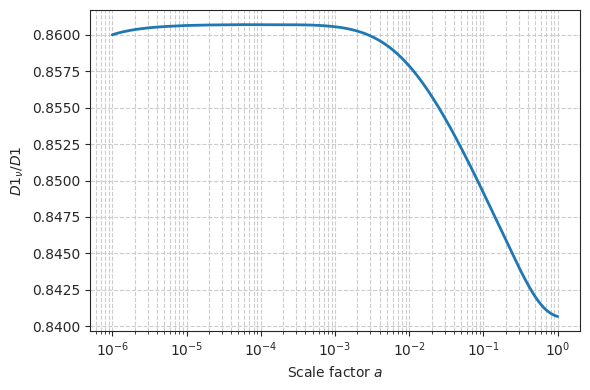

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(a, D1, label=r'$D(a)$', lw=2)
plt.plot(a, D1_nu, '--', label=r'$D_\nu(a)$', lw=2)
plt.xlabel(r'Scale factor $a$')
plt.ylabel(r'Growth factor $D1(a)$')
plt.legend(ncol=2, fontsize=9)
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()
#plt.savefig('D_norm_DJ.pgf')

#Plot [(D/D_nu)-1] (log scale)
plt.figure(figsize=(6,4))
plt.semilogx(a, D1_nu/D1, lw=2)
plt.xlabel(r'Scale factor $a$')
plt.ylabel(r'$D1_\nu/D1$')
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()
#plt.savefig('Ddiff_norm_DJ.pgf')

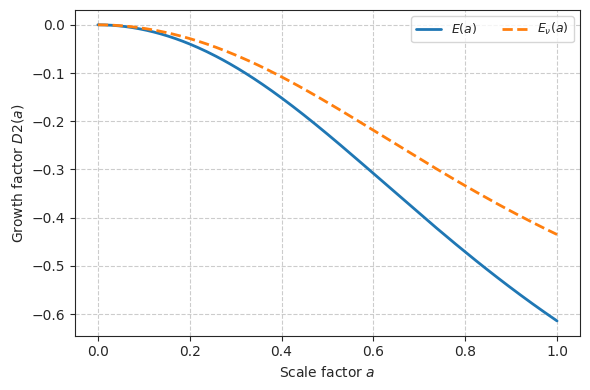

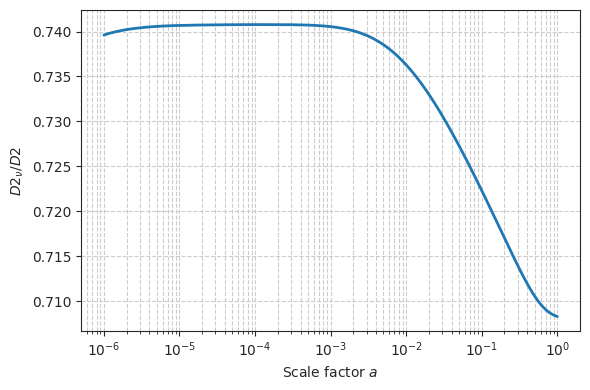

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(a, D2, label=r'$E(a)$', lw=2)
plt.plot(a, D2_nu, '--', label=r'$E_\nu(a)$', lw=2)
plt.xlabel(r'Scale factor $a$')
plt.ylabel(r'Growth factor $D2(a)$')
plt.legend(ncol=2, fontsize=9)
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()
#plt.savefig('E.pgf')

#Plot [(E/E_nu)-1] (log scale)
plt.figure(figsize=(6,4))
plt.semilogx(a, D2_nu/D2, lw=2)
plt.xlabel(r'Scale factor $a$')
plt.ylabel(r'$D2_\nu /D2$')
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()